## 1. Install Library

In [1]:
!pip install -q lmdb fire nltk natsort torch torchvision easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 80.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 24.7 MB/s eta 0:00:00


## 2. Download Dataset

In [2]:
!gdown 1ExX04lQBxF3QjwWJBjEpvwdHVfTi6R8Z

Downloading...
From: https://drive.google.com/uc?id=1ExX04lQBxF3QjwWJBjEpvwdHVfTi6R8Z
To: /content/dataset_easyocr.zip
100% 14.4M/14.4M [00:00<00:00, 58.2MB/s]


Unzip dataset

In [3]:
!unzip -q dataset_easyocr.zip -d data

## 3. Split Dataset (Stratified)

In [4]:

import os
import shutil
import random
from pathlib import Path

# ================= K O N F I G U R A S I =================
# Folder sumber yang berisi semua gambar dan gt.txt
SOURCE_FOLDER = 'data/dataset_easyocr'

# Folder tujuan output
OUTPUT_BASE = 'clean_data'

# Rasio pembagian
TRAIN_RATIO = 0.8  # 80% untuk Training
VAL_RATIO = 0.1    # 10% untuk Validation
                   # Sisa 10% otomatis untuk Test

# Seed untuk Reproducibility
SEED = 44          # Anda bisa mengganti angka ini dengan angka berapapun
# =========================================================

def split_dataset():
    # Set seed untuk module random agar hasil shuffle selalu sama
    random.seed(SEED)
    print(f"Menggunakan Random Seed: {SEED}")

    # 1. Siapkan path folder tujuan
    train_dir = os.path.join(OUTPUT_BASE, 'train')
    val_dir = os.path.join(OUTPUT_BASE, 'val')
    test_dir = os.path.join(OUTPUT_BASE, 'test')

    # Hapus folder output lama jika ada (biar bersih)
    if os.path.exists(OUTPUT_BASE):
        shutil.rmtree(OUTPUT_BASE)

    os.makedirs(train_dir)
    os.makedirs(val_dir)
    os.makedirs(test_dir)

    print(f"Folder output dibuat: {OUTPUT_BASE}")

    # 2. Baca file gt.txt utama
    gt_path = os.path.join(SOURCE_FOLDER, 'gt.txt')
    if not os.path.exists(gt_path):
        print(f"Error: File gt.txt tidak ditemukan di {SOURCE_FOLDER}")
        return

    with open(gt_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Bersihkan baris kosong
    lines = [line.strip() for line in lines if line.strip()]

    # ---------------------------------------------------------
    # MODIFIKASI: Stratify Split Logic (Train, Val, Test)
    # ---------------------------------------------------------
    top_lines = []
    bottom_lines = []
    other_lines = []

    # Pisahkan data berdasarkan nama file
    for line in lines:
        parts = line.split('\t')
        filename = parts[0]

        if '_top' in filename:
            top_lines.append(line)
        elif '_bottom' in filename:
            bottom_lines.append(line)
        else:
            other_lines.append(line)

    # Acak masing-masing kategori secara independen
    # Karena kita sudah set random.seed(42) di atas,
    # hasil shuffle ini akan selalu sama setiap kali script dijalankan.
    random.shuffle(top_lines)
    random.shuffle(bottom_lines)
    random.shuffle(other_lines)

    # Fungsi internal untuk memotong list menjadi 3 bagian
    def get_splits(data_list):
        total = len(data_list)
        train_end = int(total * TRAIN_RATIO)
        val_end = train_end + int(total * VAL_RATIO)

        train_split = data_list[:train_end]
        val_split = data_list[train_end:val_end]
        test_split = data_list[val_end:]
        return train_split, val_split, test_split

    # Bagi data untuk masing-masing kategori
    train_top, val_top, test_top = get_splits(top_lines)
    train_bottom, val_bottom, test_bottom = get_splits(bottom_lines)
    train_other, val_other, test_other = get_splits(other_lines)

    # Gabungkan kembali
    train_data = train_top + train_bottom + train_other
    val_data = val_top + val_bottom + val_other
    test_data = test_top + test_bottom + test_other

    # Acak ulang hasil gabungan
    random.shuffle(train_data)
    random.shuffle(val_data)
    random.shuffle(test_data)

    print(f"Total Data: {len(lines)}")
    print(f"  - Top    : {len(top_lines)}")
    print(f"  - Bottom : {len(bottom_lines)}")
    print("-" * 40)
    print(f"Train Set : {len(train_data)} (Top: {len(train_top)}, Btm: {len(train_bottom)})")
    print(f"Val Set   : {len(val_data)} (Top: {len(val_top)}, Btm: {len(val_bottom)})")
    print(f"Test Set  : {len(test_data)} (Top: {len(test_top)}, Btm: {len(test_bottom)})")
    print("-" * 40)

    # 4. Fungsi pembantu untuk menyalin
    def process_split(data_lines, target_folder):
        new_gt_lines = []
        copied_count = 0

        for line in data_lines:
            parts = line.split('\t')
            if len(parts) < 2: continue

            filename = parts[0]
            label = parts[1]

            src_img = os.path.join(SOURCE_FOLDER, filename)
            dst_img = os.path.join(target_folder, filename)

            # Copy gambar jika ada
            if os.path.exists(src_img):
                shutil.copy(src_img, dst_img)
                new_gt_lines.append(line)
                copied_count += 1
            else:
                print(f"Warning: Gambar {filename} tidak ditemukan di source.")

        # Tulis gt.txt baru di folder target
        target_gt_path = os.path.join(target_folder, 'gt.txt')
        with open(target_gt_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(new_gt_lines))

        return copied_count

    # 5. Eksekusi Copy
    print("Sedang menyalin data Train...")
    process_split(train_data, train_dir)

    print("Sedang menyalin data Val...")
    process_split(val_data, val_dir)

    print("Sedang menyalin data Test...")
    process_split(test_data, test_dir)

    print("\n" + "="*40)
    print("STRATIFIED SPLIT SELESAI")
    print("="*40)
    print(f"Output folder: {OUTPUT_BASE}")
    print("Siap untuk dikonversi ke LMDB.")

if __name__ == '__main__':
    split_dataset()


Menggunakan Random Seed: 44
Folder output dibuat: clean_data
Total Data: 2908
  - Top    : 1454
  - Bottom : 1454
----------------------------------------
Train Set : 2326 (Top: 1163, Btm: 1163)
Val Set   : 290 (Top: 145, Btm: 145)
Test Set  : 292 (Top: 146, Btm: 146)
----------------------------------------
Sedang menyalin data Train...
Sedang menyalin data Val...
Sedang menyalin data Test...

STRATIFIED SPLIT SELESAI
Output folder: clean_data
Siap untuk dikonversi ke LMDB.


In [5]:
!zip -r clean_data.zip clean_data

  adding: clean_data/ (stored 0%)
  adding: clean_data/train/ (stored 0%)
  adding: clean_data/train/SANX31_bottom.jpeg (deflated 7%)
  adding: clean_data/train/HE39_top.jpeg (deflated 3%)
  adding: clean_data/train/Q64_bottom.jpeg (deflated 4%)
  adding: clean_data/train/1 (285)_bottom.jpg (deflated 5%)
  adding: clean_data/train/1 (730)_top.jpg (deflated 7%)
  adding: clean_data/train/1 (801)_top.jpg (deflated 4%)
  adding: clean_data/train/HEXING 93_bottom.jpg (deflated 8%)
  adding: clean_data/train/1 (451)_top.jpg (deflated 1%)
  adding: clean_data/train/Q63_top.jpeg (deflated 4%)
  adding: clean_data/train/EL16_top.jpeg (deflated 3%)
  adding: clean_data/train/1 (543)_bottom.jpg (deflated 1%)
  adding: clean_data/train/MET41_top.jpeg (deflated 3%)
  adding: clean_data/train/1 (347)_top.jpg (deflated 4%)
  adding: clean_data/train/1 (60)_top.jpg (deflated 3%)
  adding: clean_data/train/1 (66)_top.jpg (deflated 1%)
  adding: clean_data/train/1 (369)_top.jpeg (deflated 5%)
  adding:

## 4. Setup EasyOCR

### Clone EasyOCR

In [6]:
!git clone https://github.com/lhfazry/deep-text-recognition-benchmark

Cloning into 'deep-text-recognition-benchmark'...
remote: Enumerating objects: 564, done.
remote: Counting objects: 100% (243/243), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 564 (delta 215), reused 210 (delta 203), pack-reused 321 (from 2)
Receiving objects: 100% (564/564), 3.49 MiB | 9.41 MiB/s, done.
Resolving deltas: 100% (334/334), done.


### Pindah Direktory

In [7]:
%cd deep-text-recognition-benchmark

/content/deep-text-recognition-benchmark


### Visualisasi Augmentation

/content/deep-text-recognition-benchmark/visualize_augmentation.py:374: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


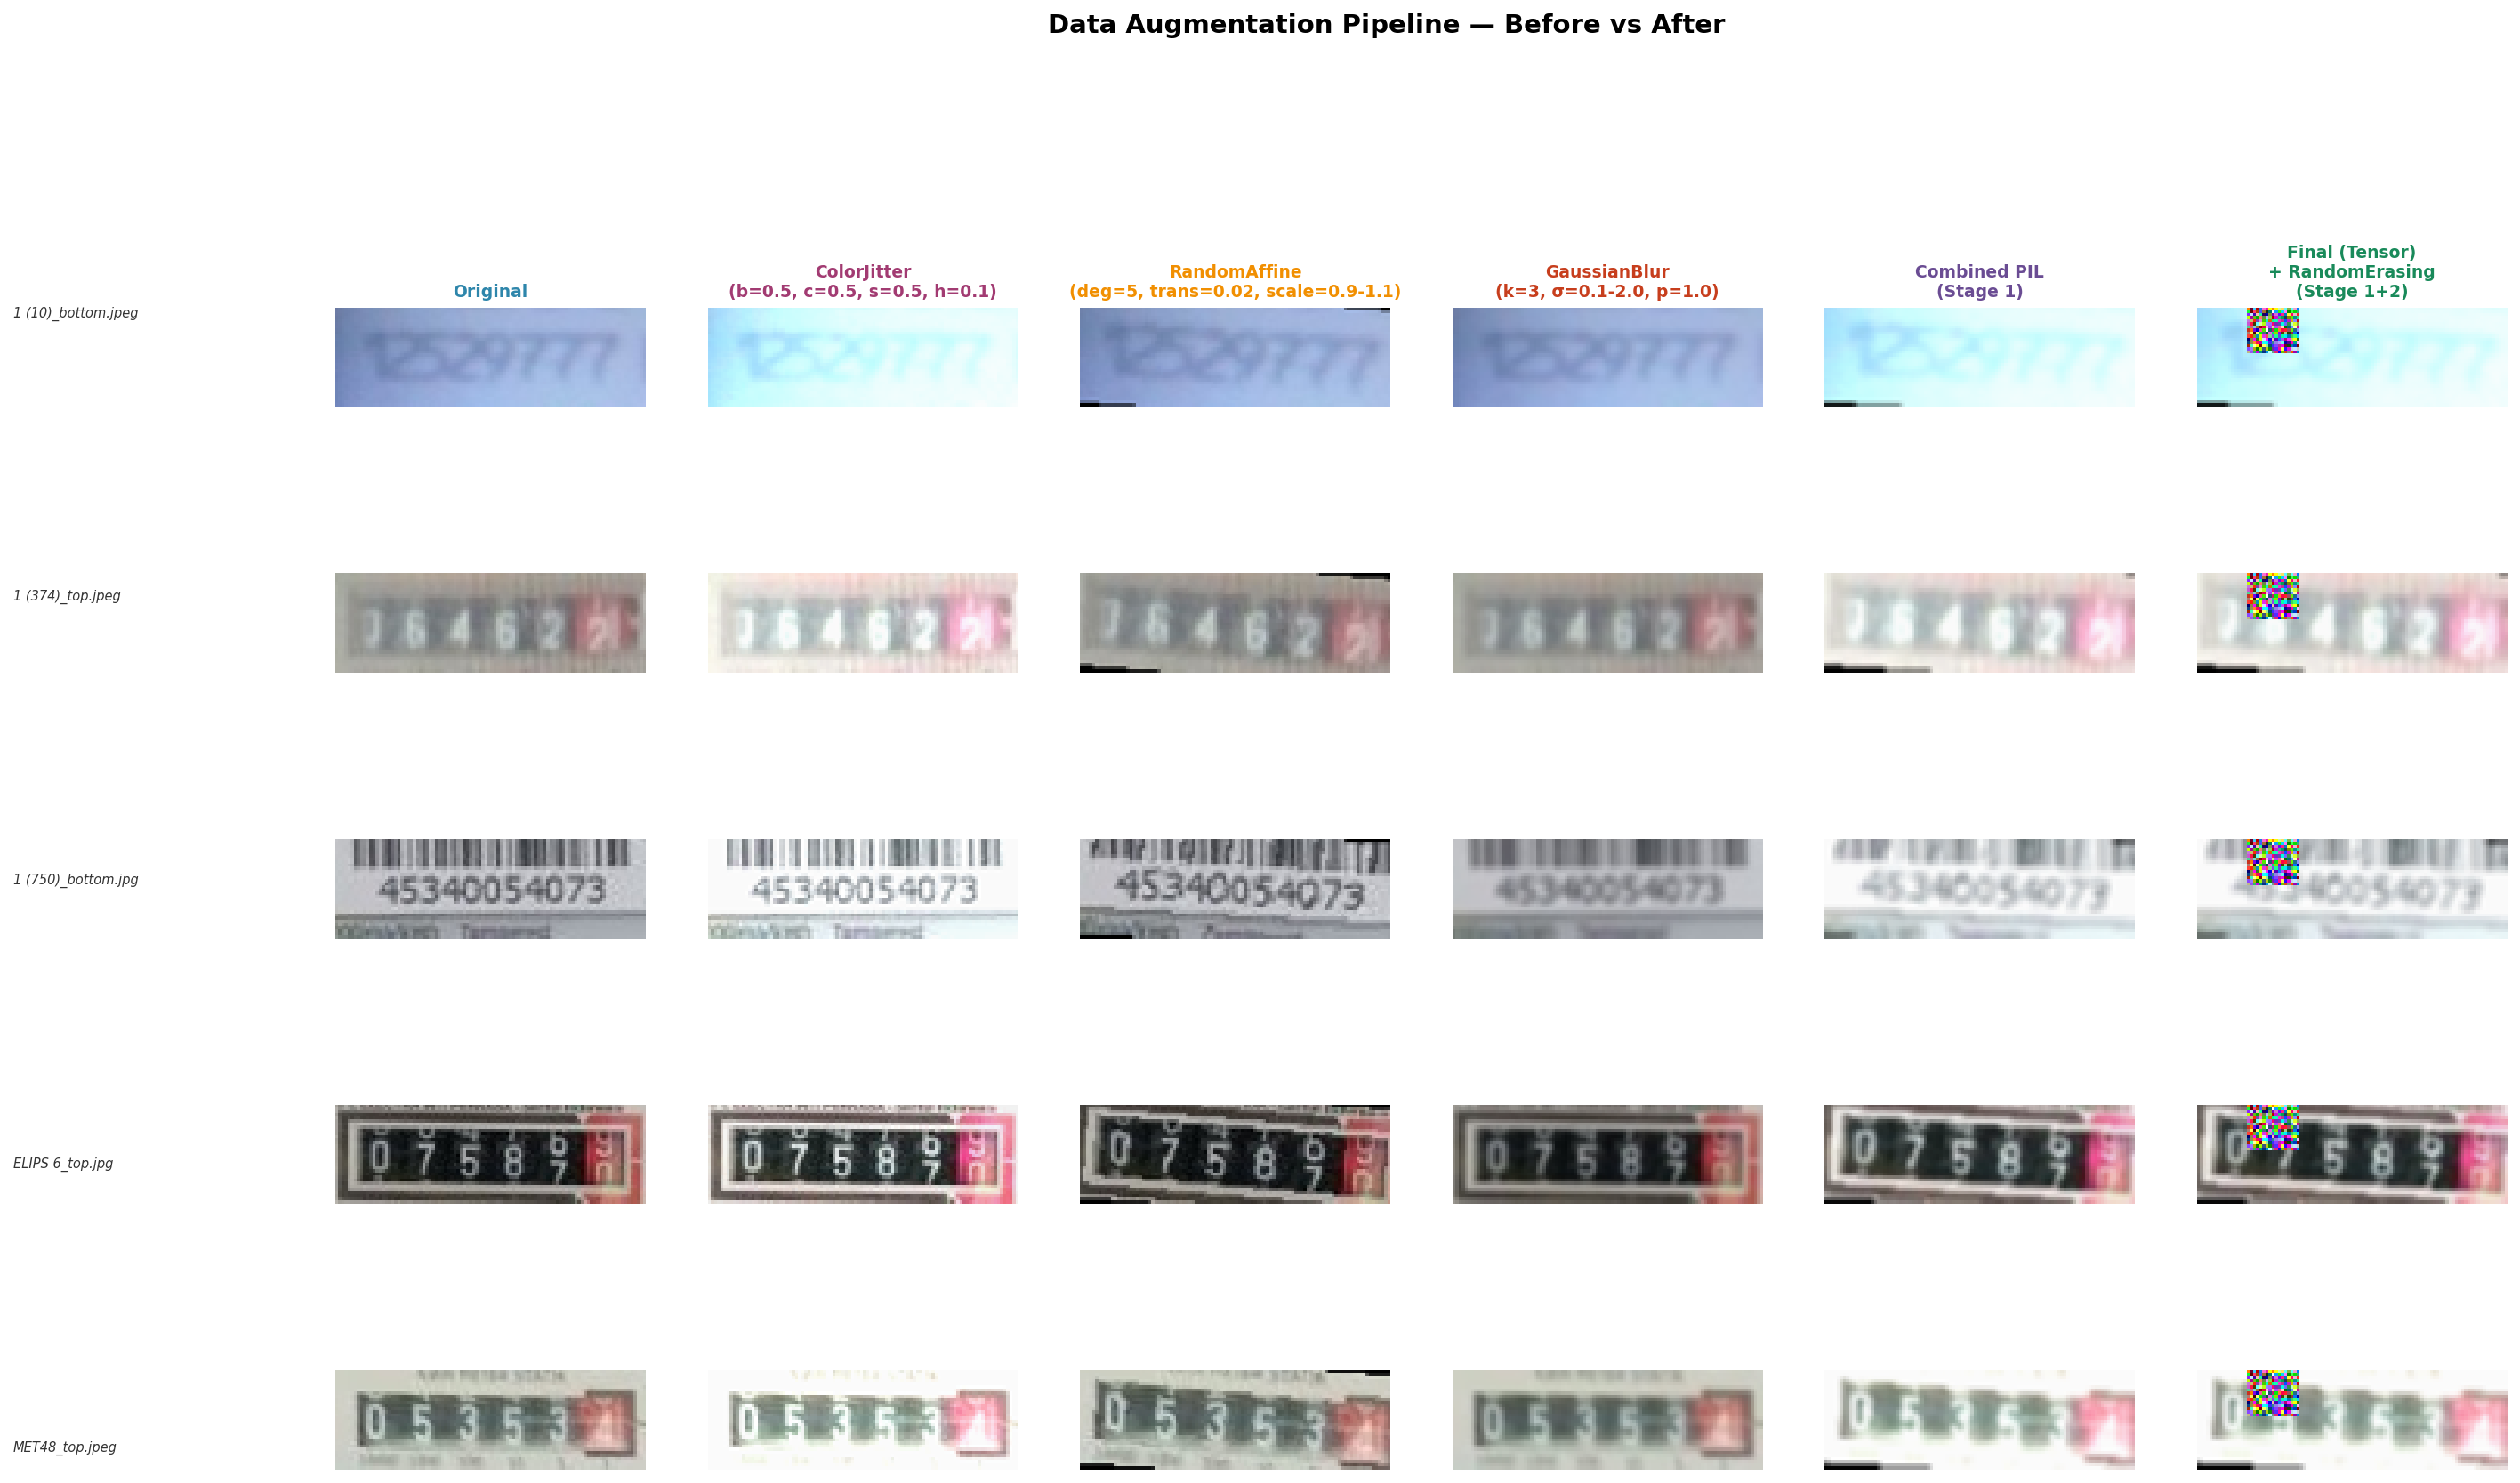

In [8]:
from visualize_augmentation import visualize_augmentations

visualize_augmentations(image_dir='/content/clean_data/train', num_samples=5)

## 4. Data Pre-processing

### 4.1 Convert to LMBD Format

LMDB adalah format standar easy ocr

#### Convert ke Format LMDB Menggunakan Script `create_lmdb.py`

In [ ]:
# Konversi Train Data
!python create_lmdb_dataset.py --inputPath /content/clean_data/train/ --gtFile /content/clean_data/train/gt.txt --outputPath /content/data_lmdb/train/

# Konversi Val Data
!python create_lmdb_dataset.py --inputPath /content/clean_data/val/ --gtFile /content/clean_data/val/gt.txt --outputPath /content/data_lmdb/val/

# Konversi Test Data
!python create_lmdb_dataset.py --inputPath /content/clean_data/test/ --gtFile /content/clean_data/test/gt.txt --outputPath /content/data_lmdb/test/

ResNet

In [ ]:
# Definisikan karakter yang ingin dipelajari (tambahkan simbol jika perlu)
# Contoh: angka dan huruf kapital saja
# chars = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
chars = "0123456789"#
# Jalankan Training
%cd deep-text-recognition-benchmark
!python train.py \
--train_data /content/data_lmdb/train \
--valid_data /content/data_lmdb/val \
--select_data / \
--batch_ratio 1.0 \
--Transformation TPS --FeatureExtraction ResNet --SequenceModeling BiLSTM --Prediction CTC \
--data_filtering_off \
--data_augmentation \
--workers 0 \
--num_iter 1000 \
--valInterval 100 \
--output_channel 512 \
--hidden_size 192 \
--character "0123456789"

PLOT

In [ ]:
!python plot_logs.py --log_path saved_models/TPS-ResNet-BiLSTM-CTC-Seed1111/log_train.txt

In [ ]:
from IPython.display import Image, display

display(Image(filename='plots/loss_plot.png'))
display(Image(filename='plots/accuracy_plot.png'))

In [ ]:
!zip -r TPS-ResNet-BiLSTM-CTC-Seed1111.zip saved_models/TPS-ResNet-BiLSTM-CTC-Seed1111

In [ ]:
!python test.py \
--eval_data /content/data_lmdb/test/ \
--Transformation TPS \
--FeatureExtraction ResNet \
--SequenceModeling BiLSTM \
--Prediction CTC \
--saved_model saved_models/TPS-ResNet-BiLSTM-CTC-Seed1111/best_accuracy.pth \
--output_channel 512 \
--hidden_size 192 \
--character "0123456789"


In [ ]:
from IPython.display import Image, display

display(Image(filename='result/TPS-ResNet-BiLSTM-CTC-Seed1111_best_accuracy.pth/confidence_distribution.png'))
display(Image(filename='result/TPS-ResNet-BiLSTM-CTC-Seed1111_best_accuracy.pth/confusion_matrix.png'))
display(Image(filename='result/TPS-ResNet-BiLSTM-CTC-Seed1111_best_accuracy.pth/character_accuracy.png'))

In [ ]:
import pandas as pd
import numpy as np

# Path to the confusion matrix CSV file from the last run (ResNet_CBAM model)
# Ensure the current working directory is /content/deep-text-recognition-benchmark
confusion_matrix_path = 'result/TPS-ResNet-BiLSTM-CTC-Seed1111_best_accuracy.pth/confusion_matrix.csv'

try:
    # Load the confusion matrix
    # The first column is the actual label, so we set it as index
    df_cm = pd.read_csv(confusion_matrix_path, index_col=0)

    # Ensure index and columns are string type for consistent lookup
    df_cm.index = df_cm.index.astype(str)
    df_cm.columns = df_cm.columns.astype(str)

    # Extract class labels (digits 0-9)
    classes = [str(i) for i in range(10)]

    # Initialize lists to store TP, FP, FN for each class
    tp_per_class = {}
    fp_per_class = {}
    fn_per_class = {}

    for c in classes:
        # True Positives (diagonal element)
        tp = df_cm.loc[c, c]
        tp_per_class[c] = tp

        # False Positives (sum of column c, excluding tp_c)
        # These are instances where other classes were predicted as c
        fp = df_cm[c].sum() - tp
        fp_per_class[c] = fp

        # False Negatives (sum of row c, excluding tp_c, and including [DELETE])
        # These are instances where c was the true label but something else was predicted or it was deleted
        fn_from_row = df_cm.loc[c, classes].sum() - tp
        fn_from_delete = df_cm.loc[c, '[DELETE]'] if '[DELETE]' in df_cm.columns else 0
        fn = fn_from_row + fn_from_delete
        fn_per_class[c] = fn

    # Calculate Micro-Average Metrics
    total_tp = sum(tp_per_class.values())
    total_fp = sum(fp_per_class.values())
    total_fn = sum(fn_per_class.values())

    # Micro Accuracy (overall character accuracy)
    # Total actual characters = total_tp + total_fn (sum of all ground truth characters)
    micro_accuracy = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0

    print("--- Character-Level Micro Averages ---")
    print(f"Micro-Accuracy: {micro_accuracy * 100:.2f}%")
    print(f"Micro-Precision: {micro_precision * 100:.2f}%")
    print(f"Micro-Recall: {micro_recall * 100:.2f}%")
    print(f"Micro-F1 Score: {micro_f1 * 100:.2f}%")
    print("\n" + "="*50 + "\n")

    # Calculate Macro-Average Metrics
    precision_scores = []
    recall_scores = []
    f1_scores = []

    print("--- Character-Level Metrics Per Class ---")
    for c in classes:
        tp = tp_per_class[c]
        fp = fp_per_class[c]
        fn = fn_per_class[c]

        precision_c = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_c = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_c = 2 * (precision_c * recall_c) / (precision_c + recall_c) if (precision_c + recall_c) > 0 else 0

        precision_scores.append(precision_c)
        recall_scores.append(recall_c)
        f1_scores.append(f1_c)

        print(f"Class {c}: P={precision_c*100:.2f}%, R={recall_c*100:.2f}%, F1={f1_c*100:.2f}%")

    macro_precision = np.mean(precision_scores)
    macro_recall = np.mean(recall_scores)
    macro_f1 = np.mean(f1_scores)

    print("\n--- Character-Level Macro Averages ---")
    print(f"Macro-Precision: {macro_precision * 100:.2f}%")
    print(f"Macro-Recall: {macro_recall * 100:.2f}%")
    print(f"Macro-F1 Score: {macro_f1 * 100:.2f}%")

except FileNotFoundError:
    print(f"Error: Confusion matrix file not found at {confusion_matrix_path}")
    print("Please ensure the 'test.py' script was run successfully and generated the confusion matrix CSV.")
except Exception as e:
    print(f"An error occurred: {e}")

# Note about Image-Level Accuracy from test.py output
print("\n" + "="*50)
print("Catatan: 'Final Accuracy' yang dilaporkan oleh test.py adalah akurasi tingkat gambar (Image-Level Accuracy).")
print("Berdasarkan output terakhir test.py untuk model ResNet_CBAM, Image-Level Accuracy adalah 86.41%.")


VGG

In [ ]:
# Definisikan karakter yang ingin dipelajari (tambahkan simbol jika perlu)
# Contoh: angka dan huruf kapital saja
# chars = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
chars = "0123456789"#
# Jalankan Training
%cd deep-text-recognition-benchmark
!python train.py \
--train_data /content/data_lmdb/train \
--valid_data /content/data_lmdb/val \
--select_data / \
--batch_ratio 1.0 \
--Transformation TPS --FeatureExtraction VGG --SequenceModeling BiLSTM --Prediction CTC \
--data_filtering_off \
--data_augmentation \
--workers 0 \
--num_iter 1000 \
--valInterval 100 \
--output_channel 512 \
--hidden_size 192 \
--character "0123456789"

PLOT VGG

In [ ]:
!python plot_logs.py --log_path saved_models/TPS-VGG-BiLSTM-CTC-Seed1111/log_train.txt

In [ ]:
from IPython.display import Image, display

display(Image(filename='plots/loss_plot.png'))
display(Image(filename='plots/accuracy_plot.png'))

In [ ]:
!zip -r TPS-VGG-BiLSTM-CTC-Seed1111.zip saved_models/TPS-VGG-BiLSTM-CTC-Seed1111

In [ ]:
!python test.py \
--eval_data /content/data_lmdb/test/ \
--Transformation TPS \
--FeatureExtraction VGG \
--SequenceModeling BiLSTM \
--Prediction CTC \
--saved_model saved_models/TPS-VGG-BiLSTM-CTC-Seed1111/best_accuracy.pth \
--output_channel 512 \
--hidden_size 192 \
--character "0123456789"


In [ ]:
from IPython.display import Image, display

display(Image(filename='result/TPS-VGG-BiLSTM-CTC-Seed1111_best_accuracy.pth/confidence_distribution.png'))
display(Image(filename='result/TPS-VGG-BiLSTM-CTC-Seed1111_best_accuracy.pth/confusion_matrix.png'))
display(Image(filename='result/TPS-VGG-BiLSTM-CTC-Seed1111_best_accuracy.pth/character_accuracy.png'))

In [ ]:
import pandas as pd
import numpy as np

# Path to the confusion matrix CSV file from the last run (ResNet_CBAM model)
# Ensure the current working directory is /content/deep-text-recognition-benchmark
confusion_matrix_path = 'result/TPS-VGG-BiLSTM-CTC-Seed1111_best_accuracy.pth/confusion_matrix.csv'

try:
    # Load the confusion matrix
    # The first column is the actual label, so we set it as index
    df_cm = pd.read_csv(confusion_matrix_path, index_col=0)

    # Ensure index and columns are string type for consistent lookup
    df_cm.index = df_cm.index.astype(str)
    df_cm.columns = df_cm.columns.astype(str)

    # Extract class labels (digits 0-9)
    classes = [str(i) for i in range(10)]

    # Initialize lists to store TP, FP, FN for each class
    tp_per_class = {}
    fp_per_class = {}
    fn_per_class = {}

    for c in classes:
        # True Positives (diagonal element)
        tp = df_cm.loc[c, c]
        tp_per_class[c] = tp

        # False Positives (sum of column c, excluding tp_c)
        # These are instances where other classes were predicted as c
        fp = df_cm[c].sum() - tp
        fp_per_class[c] = fp

        # False Negatives (sum of row c, excluding tp_c, and including [DELETE])
        # These are instances where c was the true label but something else was predicted or it was deleted
        fn_from_row = df_cm.loc[c, classes].sum() - tp
        fn_from_delete = df_cm.loc[c, '[DELETE]'] if '[DELETE]' in df_cm.columns else 0
        fn = fn_from_row + fn_from_delete
        fn_per_class[c] = fn

    # Calculate Micro-Average Metrics
    total_tp = sum(tp_per_class.values())
    total_fp = sum(fp_per_class.values())
    total_fn = sum(fn_per_class.values())

    # Micro Accuracy (overall character accuracy)
    # Total actual characters = total_tp + total_fn (sum of all ground truth characters)
    micro_accuracy = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0

    print("--- Character-Level Micro Averages ---")
    print(f"Micro-Accuracy: {micro_accuracy * 100:.2f}%")
    print(f"Micro-Precision: {micro_precision * 100:.2f}%")
    print(f"Micro-Recall: {micro_recall * 100:.2f}%")
    print(f"Micro-F1 Score: {micro_f1 * 100:.2f}%")
    print("\n" + "="*50 + "\n")

    # Calculate Macro-Average Metrics
    precision_scores = []
    recall_scores = []
    f1_scores = []

    print("--- Character-Level Metrics Per Class ---")
    for c in classes:
        tp = tp_per_class[c]
        fp = fp_per_class[c]
        fn = fn_per_class[c]

        precision_c = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_c = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_c = 2 * (precision_c * recall_c) / (precision_c + recall_c) if (precision_c + recall_c) > 0 else 0

        precision_scores.append(precision_c)
        recall_scores.append(recall_c)
        f1_scores.append(f1_c)

        print(f"Class {c}: P={precision_c*100:.2f}%, R={recall_c*100:.2f}%, F1={f1_c*100:.2f}%")

    macro_precision = np.mean(precision_scores)
    macro_recall = np.mean(recall_scores)
    macro_f1 = np.mean(f1_scores)

    print("\n--- Character-Level Macro Averages ---")
    print(f"Macro-Precision: {macro_precision * 100:.2f}%")
    print(f"Macro-Recall: {macro_recall * 100:.2f}%")
    print(f"Macro-F1 Score: {macro_f1 * 100:.2f}%")

except FileNotFoundError:
    print(f"Error: Confusion matrix file not found at {confusion_matrix_path}")
    print("Please ensure the 'test.py' script was run successfully and generated the confusion matrix CSV.")
except Exception as e:
    print(f"An error occurred: {e}")

# Note about Image-Level Accuracy from test.py output
print("\n" + "="*50)
print("Catatan: 'Final Accuracy' yang dilaporkan oleh test.py adalah akurasi tingkat gambar (Image-Level Accuracy).")
print("Berdasarkan output terakhir test.py untuk model ResNet_CBAM, Image-Level Accuracy adalah 86.41%.")


## 7. Training

### CustomAttentionCNN

In [ ]:
!python train.py \
--exp_name TPS-CustomAttentionCNN-BiLSTM-Attn \
--train_data /content/data_lmdb/train/ \
--valid_data /content/data_lmdb/val \
--select_data / \
--batch_ratio 1.0 \
--Transformation TPS \
--FeatureExtraction CustomAttentionCNN \
--SequenceModeling BiLSTM \
--Prediction Attn \
--data_augmentation \
--workers 0 \
--num_iter 1000 \
--valInterval 100 \
--output_channel 512 \
--hidden_size 192 \
--early_stopping_patience 10 \
--character "0123456789"

#### Plot Training Validation Loss

In [ ]:
!python plot_logs.py --log_path saved_models/TPS-CustomAttentionCNN-BiLSTM-Attn/log_train.txt

In [ ]:
from IPython.display import Image, display

display(Image(filename='plots/loss_plot.png'))
display(Image(filename='plots/accuracy_plot.png'))

#### Zip Trained Model

In [ ]:
!zip -r TPS-CustomAttentionCNN-BiLSTM-Attn.zip saved_models/TPS-CustomAttentionCNN-BiLSTM-Attn

### Test

In [ ]:
!python test.py \
--eval_data /content/data_lmdb/test/ \
--Transformation TPS \
--FeatureExtraction CustomAttentionCNN \
--SequenceModeling BiLSTM \
--Prediction Attn \
--saved_model saved_models/TPS-CustomAttentionCNN-BiLSTM-Attn/best_accuracy.pth \
--output_channel 512 \
--hidden_size 192 \
--character "0123456789"


In [ ]:
from IPython.display import Image, display

display(Image(filename='result/TPS-CustomAttentionCNN-BiLSTM-Attn_best_accuracy.pth/confidence_distribution.png'))
display(Image(filename='result/TPS-CustomAttentionCNN-BiLSTM-Attn_best_accuracy.pth/confusion_matrix.png'))
display(Image(filename='result/TPS-CustomAttentionCNN-BiLSTM-Attn_best_accuracy.pth/character_accuracy.png'))

### CustomCBAMCNN

In [ ]:
!python train.py \
--exp_name TPS-CustomCBAMCNN-BiLSTM-Attn \
--train_data /content/data_lmdb/train/ \
--valid_data /content/data_lmdb/val \
--select_data / \
--batch_ratio 1.0 \
--Transformation TPS \
--FeatureExtraction RCNN \
--SequenceModeling BiLSTM \
--Prediction Attn \
--data_augmentation \
--workers 0 \
--num_iter 1000 \
--valInterval 100 \
--output_channel 512 \
--hidden_size 192 \
--early_stopping_patience 5 \
--character "0123456789"

#### Plot Training Validation Loss

In [ ]:
!python plot_logs.py --log_path saved_models/TPS-CustomCBAMCNN-BiLSTM-Attn/log_train.txt

In [ ]:
from IPython.display import Image, display

display(Image(filename='plots/loss_plot.png'))
display(Image(filename='plots/accuracy_plot.png'))

#### Zip Trained Model

In [ ]:
!zip -r TPS-CustomCBAMCNN-BiLSTM-Attn.zip saved_models/TPS-CustomCBAMCNN-BiLSTM-Attn

### Test

In [ ]:
!python test.py \
--eval_data /content/data_lmdb/test/ \
--Transformation TPS \
--FeatureExtraction CustomCBAMCNN \
--SequenceModeling BiLSTM \
--Prediction Attn \
--saved_model saved_models/TPS-CustomCBAMCNN-BiLSTM-Attn/best_accuracy.pth \
--output_channel 512 \
--hidden_size 192 \
--character "0123456789"


In [ ]:
from IPython.display import Image, display

display(Image(filename='result/TPS-CustomCBAMCNN-BiLSTM-Attn_best_accuracy.pth/confidence_distribution.png'))
display(Image(filename='result/TPS-CustomCBAMCNN-BiLSTM-Attn_best_accuracy.pth/confusion_matrix.png'))
display(Image(filename='result/TPS-CustomCBAMCNN-BiLSTM-Attn_best_accuracy.pth/character_accuracy.png'))

### ResNet_CBAM

In [ ]:
!python train.py \
--exp_name TPS-ResNet_CBAM-BiLSTM-CTC \
--train_data /content/data_lmdb/train/ \
--valid_data /content/data_lmdb/val \
--select_data / \
--batch_ratio 1.0 \
--Transformation TPS \
--FeatureExtraction ResNet_CBAM \
--SequenceModeling BiLSTM \
--Prediction CTC \
--data_filtering_off \
--data_augmentation \
--workers 0 \
--num_iter 1000 \
--valInterval 100 \
--output_channel 512 \
--hidden_size 192 \
--early_stopping_patience 10 \
--character "0123456789"

#### Plot Training Validation Loss

In [ ]:
!python plot_logs.py --log_path saved_models/TPS-ResNet_CBAM-BiLSTM-CTC/log_train.txt

In [ ]:
from IPython.display import Image, display

display(Image(filename='plots/loss_plot.png'))
display(Image(filename='plots/accuracy_plot.png'))

#### Zip Trained Model

In [ ]:
!zip -r TPS-ResNet_CBAM-BiLSTM-CTC.zip saved_models/TPS-ResNet_CBAM-BiLSTM-CTC

### Test

In [ ]:
!python test.py \
--eval_data /content/data_lmdb/test/ \
--Transformation TPS \
--FeatureExtraction ResNet_CBAM \
--SequenceModeling BiLSTM \
--Prediction CTC \
--saved_model saved_models/TPS-ResNet_CBAM-BiLSTM-CTC/best_accuracy.pth \
--output_channel 512 \
--hidden_size 192 \
--character "0123456789"


In [ ]:
from IPython.display import Image, display

display(Image(filename='result/TPS-ResNet_CBAM-BiLSTM-CTC_best_accuracy.pth/confidence_distribution.png'))
display(Image(filename='result/TPS-ResNet_CBAM-BiLSTM-CTC_best_accuracy.pth/confusion_matrix.png'))
display(Image(filename='result/TPS-ResNet_CBAM-BiLSTM-CTC_best_accuracy.pth/character_accuracy.png'))

### Detailed Ground Truth vs. Prediction Comparison for all Test Samples

In [ ]:
import pandas as pd
import numpy as np

# Path to the confusion matrix CSV file from the last run (ResNet_CBAM model)
# Ensure the current working directory is /content/deep-text-recognition-benchmark
confusion_matrix_path = 'result/TPS-ResNet_CBAM-BiLSTM-CTC_best_accuracy.pth/confusion_matrix.csv'

try:
    # Load the confusion matrix
    # The first column is the actual label, so we set it as index
    df_cm = pd.read_csv(confusion_matrix_path, index_col=0)

    # Ensure index and columns are string type for consistent lookup
    df_cm.index = df_cm.index.astype(str)
    df_cm.columns = df_cm.columns.astype(str)

    # Extract class labels (digits 0-9)
    classes = [str(i) for i in range(10)]

    # Initialize lists to store TP, FP, FN for each class
    tp_per_class = {}
    fp_per_class = {}
    fn_per_class = {}

    for c in classes:
        # True Positives (diagonal element)
        tp = df_cm.loc[c, c]
        tp_per_class[c] = tp

        # False Positives (sum of column c, excluding tp_c)
        # These are instances where other classes were predicted as c
        fp = df_cm[c].sum() - tp
        fp_per_class[c] = fp

        # False Negatives (sum of row c, excluding tp_c, and including [DELETE])
        # These are instances where c was the true label but something else was predicted or it was deleted
        fn_from_row = df_cm.loc[c, classes].sum() - tp
        fn_from_delete = df_cm.loc[c, '[DELETE]'] if '[DELETE]' in df_cm.columns else 0
        fn = fn_from_row + fn_from_delete
        fn_per_class[c] = fn

    # Calculate Micro-Average Metrics
    total_tp = sum(tp_per_class.values())
    total_fp = sum(fp_per_class.values())
    total_fn = sum(fn_per_class.values())

    # Micro Accuracy (overall character accuracy)
    # Total actual characters = total_tp + total_fn (sum of all ground truth characters)
    micro_accuracy = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0

    print("--- Character-Level Micro Averages ---")
    print(f"Micro-Accuracy: {micro_accuracy * 100:.2f}%")
    print(f"Micro-Precision: {micro_precision * 100:.2f}%")
    print(f"Micro-Recall: {micro_recall * 100:.2f}%")
    print(f"Micro-F1 Score: {micro_f1 * 100:.2f}%")
    print("\n" + "="*50 + "\n")

    # Calculate Macro-Average Metrics
    precision_scores = []
    recall_scores = []
    f1_scores = []

    print("--- Character-Level Metrics Per Class ---")
    for c in classes:
        tp = tp_per_class[c]
        fp = fp_per_class[c]
        fn = fn_per_class[c]

        precision_c = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_c = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_c = 2 * (precision_c * recall_c) / (precision_c + recall_c) if (precision_c + recall_c) > 0 else 0

        precision_scores.append(precision_c)
        recall_scores.append(recall_c)
        f1_scores.append(f1_c)

        print(f"Class {c}: P={precision_c*100:.2f}%, R={recall_c*100:.2f}%, F1={f1_c*100:.2f}%")

    macro_precision = np.mean(precision_scores)
    macro_recall = np.mean(recall_scores)
    macro_f1 = np.mean(f1_scores)

    print("\n--- Character-Level Macro Averages ---")
    print(f"Macro-Precision: {macro_precision * 100:.2f}%")
    print(f"Macro-Recall: {macro_recall * 100:.2f}%")
    print(f"Macro-F1 Score: {macro_f1 * 100:.2f}%")

except FileNotFoundError:
    print(f"Error: Confusion matrix file not found at {confusion_matrix_path}")
    print("Please ensure the 'test.py' script was run successfully and generated the confusion matrix CSV.")
except Exception as e:
    print(f"An error occurred: {e}")

# Note about Image-Level Accuracy from test.py output
print("\n" + "="*50)
print("Catatan: 'Final Accuracy' yang dilaporkan oleh test.py adalah akurasi tingkat gambar (Image-Level Accuracy).")
print("Berdasarkan output terakhir test.py untuk model ResNet_CBAM, Image-Level Accuracy adalah 86.41%.")


## SINGLE INFERENCE


In [ ]:
!python inference.py \
    --image_path "demo_image/MELCO 3.jpg" \
    --Transformation TPS \
    --FeatureExtraction ResNet \
    --SequenceModeling BiLSTM \
    --Prediction CTC \
    --saved_model saved_model/TPS-ResNet-BiLSTM-CTC-Seed1111/best_accuracy.pth \
    --output_channel 512 \
    --hidden_size 192 \
    --character "0123456789"

In [ ]:
! pip install ultralytics

In [ ]:
!python pipeline.py \
    --image_path "demo_image/MELCO3.jpg" \
    --Transformation TPS \
    --FeatureExtraction ResNet \
    --SequenceModeling BiLSTM \
    --Prediction CTC \
    --saved_model saved_model/TPS-ResNet-BiLSTM-CTC-Seed1111/best_accuracy.pth \
    --yolo_model yolo_model/best.pt \
    --output_channel 512 \
    --hidden_size 192 \
    --character "0123456789"

In [ ]:
!ls